# Simple Linear Regression — *Estimating Prep Time from Tonight's Cover Count*

A first machine learning notebook, framed in the language of kitchen
planning. We will treat the number of covers (guests) as the input
and the total prep time in hours as the quantity to predict. The
definitions, formulas, and code stay the same for every learner;
only this story changes.

## The story

You keep a logbook of past service nights: how many covers were
booked, and how long mise en place actually took. From those entries
you have a list of `(covers, prep hours)` pairs.

Your job in this notebook: learn a simple rule that turns tonight's
booking number into a reliable prep-time estimate — the same way a
recipe scaling factor turns "serves 4" into "serves 40".

## Glossary — your field ↔ ML

Mental bridge between kitchen thinking and the ML vocabulary below.
In this notebook, **`x` is the number of covers (dinner guests)**
and **`y` is total prep time in hours**. Everything else is just
renamed kitchen planning.

| Your field | ML term | Short bridge |
|------------|---------|--------------|
| Number of covers booked | feature | The input the model reads. |
| Prep time needed | target | The quantity to predict. |
| Your logbook of past service nights | training data | Points the model adjusts on. |
| Nights you kept aside to check accuracy | test data | Points the model never sees during fitting. |
| Splitting the logbook into "fit" and "check" nights | train/test split | Protocol for honest evaluation. |
| The scaling rule you use to estimate prep | model | The rule whose constants you tune. |
| The slope and intercept of the scaling rule | parameters / weights | The numbers learning adjusts. |
| Baseline time even for zero covers (cleaning, setup) | bias | The constant term of the prediction. |
| Estimated prep time for tonight's booking | prediction | Model output for new inputs. |
| (actual prep time − estimated) on a given night | residual | Per-point error after fitting. |
| Total squared estimation errors across all nights | loss | Single number measuring total wrongness. |
| Average of those squared errors | mean squared error / MSE | Most common regression loss. |
| Direction to nudge the rule to cut errors | gradient | Direction of steepest cost increase. |
| Tiny repeated adjustments to the rule | gradient descent | Small parameter updates that follow the gradient downhill. |
| How boldly you change the rule each step | learning rate | How big each update is. |
| One full pass through all your logged nights | epoch | One sweep through training data. |
| A rule so tailored to past nights it misfires on new ones | overfitting | Model memorises noise, generalises poorly. |
| A rule too simple to capture the real pattern | underfitting | Model too blunt to catch the signal. |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## 1. Setting the scene

Each observation here is one past service night: an `(x, y)` pair
where `x` is the cover count and `y` is hours of prep. The glossary
above gives the full vocabulary mapping. The next cell defines the
ML terms.

### Core vocabulary

- **feature** — the input variable, here `x`.
- **target** — the quantity we want to predict, here `y`.
- A dataset is a collection of `(feature, target)` pairs.
- **training data** — the subset used to fit the model.
- **test data** — the subset held back to evaluate the model honestly.
- **train/test split** — the act of partitioning the dataset into
  training data and test data.

### In your field

In this notebook, the **feature** `x` is the cover count (number of
guests booked) and the **target** `y` is total prep time in hours.
Your **training data** is the logbook of past service nights; the
**test data** is a handful of nights you set aside to check whether
the rule still works on bookings it has never seen. Splitting your
logbook into "fit" and "check" nights *is* a **train/test split**.

In [2]:
# Synthetic ground truth: y = 0.25 * x + 1.0 + small noise
true_slope = 0.25
true_intercept = 1.0

x_data = rng.uniform(10, 200, size=80)
noise = rng.normal(0, 3.0, size=x_data.shape)
y_data = true_slope * x_data + true_intercept + noise

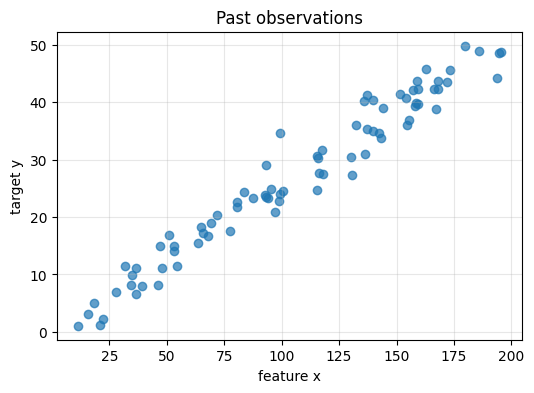

In [3]:
# Each dot is one past service night — cover count on x, prep hours on y.

plt.figure(figsize=(6, 4))
plt.scatter(x_data, y_data, alpha=0.7)
plt.xlabel("feature x")
plt.ylabel("target y")
plt.title("Past observations")
plt.grid(True, alpha=0.3)
plt.show()

### What pattern do you see?

The cloud of points slopes upward — more covers, more prep time —
exactly the scaling intuition every chef carries in their head. Our
goal is to draw the best straight line through this cloud so that for
any new booking number we can read off a reliable prep-time estimate,
the way a recipe card tells you to multiply ingredients when the
guest count changes.

### Go deeper with an LLM (optional — skip if you already know this)

Paste any prompt below into ChatGPT / Claude / Mistral, explore, then
come back.

**Prompt 1 — feature vs target in your kitchen**
```
In machine learning, what is the difference between a "feature" and a
"target"? Apply the distinction to a chef's prep-planning problem
where I want to predict tonight's prep time from the cover count.
Which is the feature, which is the target, and what would the slope
of the line represent in kitchen terms? Keep the answer to ~5 minutes
of reading so I can return to my notebook.
```

**Prompt 2 — why hold out test data**
```
Why do machine learning workflows split data into "training data" and
"test data" before fitting? Compare with keeping a few service nights
out of your logbook to check whether your rule works on nights it
has never seen. Give one realistic situation where skipping the
train/test split would make you fool yourself. Keep the answer to ~5
minutes of reading so I can return to my notebook.
```

## 2. The model — linear regression

A **linear regression model** is the rule

$$ \hat{y} = w \cdot x + b $$

where $x$ is the feature, $\hat{y}$ is the **prediction**, and $w$
and $b$ are numbers the model learns. They are called the model's
**parameters** (or **weights**, with $b$ specifically called the
**bias**). A small set of parameters that fits a lot of data — that
is the whole idea of regression.

### In your field

The slope `w` is hours of prep needed per cover (a recipe-scaling
factor) and the **bias** `b` is the fixed mise en place that has to
happen no matter how many guests show up — sharpening, stocking,
setting up stations. The **prediction** $\hat{y} = w \cdot x + b$
is the same kind of rule you carry in your head when you read the
reservation sheet on a Saturday.

### Worked example

With `w = 0.12` (hours per cover) and `b = 0.8` (baseline hours for
setup), for a booking of 60 covers the predicted prep time is
`0.12 × 60 + 0.8 = 8.0 hours`. This is exactly the mental maths a
chef does when reading the reservation sheet before a busy Saturday:
scale the main prep by cover count, then add the fixed mise en place.

In [4]:
from sklearn.linear_model import LinearRegression

X = x_data.reshape(-1, 1)   # sklearn expects a 2-D feature matrix
y = y_data

model = LinearRegression().fit(X, y)
learned_slope = float(model.coef_[0])
learned_intercept = float(model.intercept_)
learned_slope, learned_intercept

(0.25734906301152594, -0.15046939018602856)

The two numbers above are the learned **parameters**. Compare them
with the ground-truth slope (`0.12`) and intercept (`0.8`) — the
model has recovered the underlying scaling rule from noisy logbook
data, the same way averaging many tasting-panel scores recovers a
stable dish rating despite individual variation between judges.

## 3. How good is the fit? — the loss

For each training point we compute the **residual**, the gap between
the true target and the prediction:

$$ r_i = y_i - \hat{y}_i $$

Squaring and averaging gives the **mean squared error (MSE)**, the
most common **loss** for regression:

$$ \text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2 $$

A smaller loss means a better fit. "Training a model" is the search
for parameters that minimise the loss.

### In your field

A **residual** is `(actual prep hours − estimated prep hours)` for
one service night. The **MSE** is the average squared residual
across your logbook — a single number that says how reliable your
prep-time rule is. A smaller **loss** means fewer surprises during
service.

In [5]:
y_pred = model.predict(X)
residuals = y - y_pred
mse = float(np.mean(residuals ** 2))
print(f"MSE = {mse:.3f}")

MSE = 7.687


### Go deeper with an LLM (optional — skip if you already know this)

**Prompt 1 — what loss really is**
```
Explain what "loss" means in machine learning, focusing on MSE for
regression. Tie it to the idea of a chef scoring their prep estimates:
if every night you write down your predicted prep time and the actual
time, how would you boil all those errors down to one number? Is that
the same as MSE? Keep the answer to ~5 minutes of reading so I can
return to my notebook.
```

**Prompt 2 — residuals as a diagnostic**
```
What can residuals tell me beyond the MSE itself? Use a kitchen
example where the model consistently underestimates prep on Friday
nights. What would that pattern in the residuals tell me? Keep the
answer to ~5 minutes of reading so I can return to my notebook.
```

## 4. Gradient descent — learning by tiny steps

sklearn solved for the best `w, b` in one shot using linear algebra.
For larger models we cannot do that, so we use **gradient descent**.

The **gradient** of the loss with respect to a parameter tells us
which direction makes the loss grow. We step in the opposite
direction. We repeat for many **epochs** (one epoch = one full pass
over the training data), each time moving the parameters a small
amount controlled by the **learning rate**.

### In your field

**Gradient descent** is the maths version of "taste, adjust, taste
again": at each step you check the gap between predicted and actual
prep, then nudge the rule to close it. The **learning rate** is how
aggressively you adjust each time — small for fine seasoning, big
for a quick overhaul. Too aggressive and you swing past the right
answer, the way too much salt is much worse than slightly too
little.

In [6]:
# From-scratch gradient descent for the same problem.
w, b = 0.0, 0.0          # start anywhere
learning_rate = 1e-6     # small steps so the descent is visible
epochs = 8000
history = []

for epoch in range(epochs):
    y_hat = w * x_data + b
    error = y_hat - y_data                  # shape (N,)
    grad_w = 2 * np.mean(error * x_data)
    grad_b = 2 * np.mean(error)
    w -= learning_rate * grad_w
    b -= learning_rate * grad_b
    history.append(np.mean(error ** 2))

print(f"learned w = {w:.3f}, b = {b:.3f}")
print(f"final MSE = {history[-1]:.3f}")

learned w = 0.256, b = 0.001
final MSE = 7.692


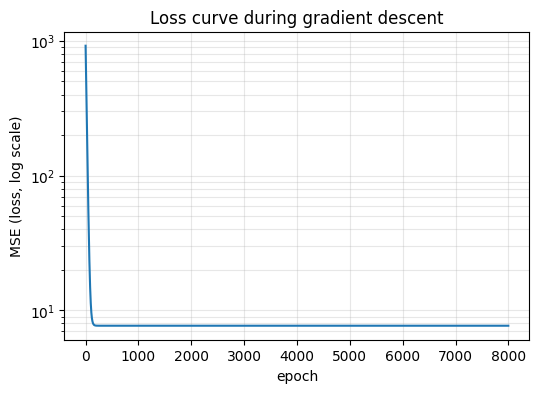

In [7]:
# Loss falling — like your estimation error shrinking as you refine the scaling rule.

# Log-scale on the y-axis spreads the descent across the whole plot,
# so we can see the slow grind that follows the initial big drop.
plt.figure(figsize=(6, 4))
plt.semilogy(history)
plt.xlabel("epoch")
plt.ylabel("MSE (loss, log scale)")
plt.title("Loss curve during gradient descent")
plt.grid(True, which="both", alpha=0.3)
plt.show()

### Why this matters

Every modern deep-learning model is trained with some flavour of
**gradient descent**. The **learning rate** controls how boldly the
rule is adjusted each step: too cautious and training takes forever;
too aggressive and it overshoots. Think of dialling a seasoning:
tiny additions when you're nearly right, bigger ones when you're far
off — except gradient descent does this automatically.

### Go deeper with an LLM (optional — skip if you already know this)

**Prompt 1 — gradient descent intuition**
```
Explain gradient descent to me as a chef. Walk through one
adjustment step — what is the gradient, why we nudge the rule in
its negative direction, what the learning rate controls — using an
analogy to adjusting seasoning in a sauce based on how far off the
taste is. Keep the answer to ~5 minutes of reading so I can return
to my notebook.
```

**Prompt 2 — when learning rate goes wrong**
```
What happens to gradient descent if the learning rate is too small,
or too large? Give a small numerical example with a simple loss and
relate it to the difference between tiny incremental seasoning
adjustments and dumping the whole salt shaker in. Keep the answer
to ~5 minutes of reading so I can return to my notebook.
```

## 5. Honest evaluation — train/test split

A model that memorises the training data is not useful. To check
whether it has truly learned the *pattern*, we hide some data
during training and only look at it at the end. That hidden portion
is the **test data**.

- **Underfitting**: the model is too simple to capture the pattern;
  loss is high on both training data and test data.
- **Overfitting**: the model has memorised noise; training loss is
  low but test loss is high.

### In your field

**Overfitting** would be a prep-time rule that perfectly explains
last month's nights but fails on a quiet Tuesday in a new season.
**Underfitting** is the opposite: a single number (e.g. "8 hours")
used for every service, ignoring how cover count actually drives
workload. **Test data** is the few nights you held back to keep
yourself honest.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)
m = LinearRegression().fit(X_train, y_train)

train_mse = float(np.mean((y_train - m.predict(X_train)) ** 2))
test_mse = float(np.mean((y_test - m.predict(X_test)) ** 2))
print(f"train MSE = {train_mse:.3f}")
print(f" test MSE = {test_mse:.3f}")

train MSE = 7.941
 test MSE = 7.144


## Try this yourself

1. Re-run the data-generation cell with a larger `noise` standard
   deviation — think a week with unusually chaotic service (big
   events, equipment failures). What happens to the MSE? To the
   recovered slope?
2. Set the learning rate to `1e-3` — very bold steps. Does training
   still converge, or does it overshoot?
3. Reduce the dataset to the first 10 points, as if your logbook
   only covered two weeks. Compare train MSE and test MSE — do you
   see overfitting?

## Recap — vocabulary you now own

**feature**, **target**, **training data**, **test data**,
**train/test split**, **model**, **parameters**, **weights**,
**bias**, **prediction**, **residual**, **loss**,
**mean squared error**, **MSE**, **gradient**, **gradient descent**,
**learning rate**, **epoch**, **overfitting**, **underfitting**.

Up next: a small **neural network** that predicts something a
straight line cannot — *tasting-panel scores from four dish
characteristics*.